In [29]:
from dataclasses import dataclass
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np 
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from torchfuzzy import FuzzyLayer, DefuzzyLinearLayer, FuzzyBellLayer, DefuzzyMaxLayer
import piqa
import sklearn.metrics as metrics
from sklearn.manifold import TSNE
from torchvision.transforms import v2
from torchinfo import summary
from matplotlib.colors import ListedColormap


In [30]:
batch_size = 256
learning_rate_ae = 1e-3
num_epochs_ae = 25
latent_dim = 4
kernels = 8
fuzzy_rules_count = 32
mnist_class_anomaly = 4
prefix = f"fuzzy_snn"
writer = SummaryWriter(f'runs/mnist/{prefix}_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ssim = piqa.SSIM(window_size = 11, n_channels=1, reduction='none').to(device)
binary_cmap = ListedColormap(['yellow', 'red'], N=2)
device

device(type='cuda')

## Датасет  

In [31]:
def norm_and_transform(x):
    nimg = x.view(-1, 28, 28)
    nimg = torch.clamp(nimg, 0, 1)
    return nimg

def clamp(x):
    #nimg = 2.0*(x.view(-1, 28, 28) - 0.5)
    nimg = torch.clamp(x, 0, 1)
    return nimg

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Lambda(norm_and_transform)
])

augmentation = transforms.Compose([
    transforms.RandomRotation(15, fill=0), 
    transforms.RandomAffine(degrees=5, translate=(0.1, 0.1), fill=0), 
    #transforms.RandomCrop(size=26),
    #transforms.Resize(size=(28, 28)),
    transforms.Lambda(clamp)
])

In [32]:
def get_target_and_mask(target_label):
    t = target_label
    return t 

train_data = datasets.MNIST(
    '~/.pytorch/MNIST_data/', 
    download=True, 
    train=True, 
    transform = transform,
    target_transform = transforms.Lambda(lambda x: get_target_and_mask(x))
)

idx = (train_data.targets != mnist_class_anomaly)
train_data.targets = train_data.targets[idx]
train_data.data = train_data.data[idx]
len(train_data)

54158

загружаем тестовую выборку

In [33]:
test_data = datasets.MNIST(
    '~/.pytorch/MNIST_data/', 
    download=True, 
    train=False, 
    transform=transform, 
    target_transform = transforms.Lambda(lambda x: get_target_and_mask(x))
)
len(test_data)

10000

Создаем итераторы датасетов

In [34]:

train_loader = torch.utils.data.DataLoader(
    train_data, 
    batch_size=batch_size, 
    shuffle=True,
    
)
test_loader = torch.utils.data.DataLoader(
    test_data, 
    batch_size=batch_size, 
    shuffle=False,
)

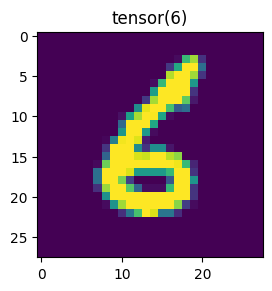

In [35]:
for img, lab in iter(train_loader):
    R, C = 1, 2
    #plt.title(lab[0])
    plt.subplot(R, C, 1)
    plt.title(lab[0])
    plt.imshow(img[0].squeeze())
    break

## Модель

In [36]:
class FSNN(nn.Module):

    def __init__(self, latent_dim, fuzzy_rules_count, decoder_input_size, kernels):
        super(FSNN, self).__init__()
                
        self.encoder = nn.Sequential(
            nn.Conv2d(1, kernels, kernel_size = 5, bias=False), 
            nn.Conv2d(kernels, kernels, kernel_size = 5, bias=False), 
            nn.BatchNorm2d(kernels, affine=False), 
            nn.SiLU(),

            nn.Conv2d(kernels, 2*kernels, kernel_size = 5, bias=False), 
            nn.Conv2d(2*kernels, 2*kernels, kernel_size = 5, bias=False), 
            nn.BatchNorm2d(2*kernels, affine=False), 
            nn.SiLU(),

            nn.Conv2d(2*kernels, 4*kernels, kernel_size = 5, bias=False), 
            nn.Conv2d(4*kernels, 4*kernels, kernel_size = 5, bias=False), 
            nn.BatchNorm2d(4*kernels, affine=False), 
            nn.SiLU(),

            nn.Conv2d(4*kernels, 8*kernels, kernel_size = 4, bias=False), 
            nn.BatchNorm2d(8*kernels, affine=False), 
            nn.Flatten(),
            nn.Linear(8*kernels, latent_dim, bias=False)
        )

        self.decoder = nn.Sequential(
            nn.Linear(decoder_input_size, 8*kernels),
            nn.BatchNorm1d(8*kernels),
            nn.Unflatten(1, (8*kernels, 1, 1)),
            
            nn.ConvTranspose2d(8*kernels, 4*kernels, 4),
            nn.BatchNorm2d(4*kernels),
            nn.SiLU(),

            nn.ConvTranspose2d(4*kernels, 2*kernels, 5),
            nn.ConvTranspose2d(2*kernels, 2*kernels, 5),
            nn.BatchNorm2d(2*kernels),
            nn.SiLU(),

            nn.ConvTranspose2d(2*kernels, kernels, 5),
            nn.ConvTranspose2d(kernels, kernels, 5),
            nn.BatchNorm2d(kernels),
            nn.SiLU(),

            nn.ConvTranspose2d(kernels, kernels, 5),
            nn.ConvTranspose2d(kernels, 1, 5),
            nn.Sigmoid(),
        )

        # main_rad = 2
        # exp_k = 1
        # sd = fuzzy_rules_count
        
        # initial_centroids = []
        # initial_scales = []

        # #initial_centroids.append(np.repeat(0, latent_dim))
        # #initial_scales.append(np.repeat(exp_k, latent_dim))
        # for x in np.linspace(0, 2 * np.pi, num = sd, endpoint=False):
        #     initial_centroids.append([exp_k * main_rad * np.sin(x), exp_k * main_rad * np.cos(x), *np.repeat(0, latent_dim-2)])
        #     initial_scales.append([exp_k, exp_k, *np.repeat(exp_k, latent_dim-2)])

        #self.fuzzy = FuzzyLayer.from_centers_and_scales(initial_centroids, initial_scales, trainable = True)
        self.fuzzy = FuzzyLayer.from_dimensions(latent_dim, fuzzy_rules_count) #FuzzyLayer.from_centers_and_scales([np.random.rand(latent_dim)], [np.repeat(1, latent_dim)], trainable = False)
        self.defuzzy = DefuzzyLinearLayer.from_dimensions(fuzzy_rules_count, decoder_input_size, with_norm = False)
       
        
    def embedding(self, x):
        return self.encoder(x)
    
    def fuzzy_inference(self, dmu):
        fz = self.fuzzy(dmu)
        dfz = self.defuzzy(fz)
        return fz, dfz
    
    def decode(self, dfz):
        return self.decoder(dfz)
    
    def forward(self, x):
        dmu = self.embedding(x)
        fz, dfz = self.fuzzy_inference(dmu)
        decoded = self.decode(dfz)
        return dmu, fz, dfz, decoded
    
    def set_freeze_fuzzy_except_centroids(self, is_freeze):
        self.fuzzy.scales.requires_grad = not is_freeze
        for r in self.fuzzy.rots:
            r.requires_grad = not is_freeze

#inp = torch.rand(10, 1, 28, 28)
#m = FSNN(latent_dim, fuzzy_rules_count, 16)
#summary(m, input_size=(batch_size, 1, 28, 28))


In [37]:
fvae = FSNN(latent_dim=latent_dim, fuzzy_rules_count=fuzzy_rules_count, decoder_input_size=64, kernels=kernels).to(device)

num_params = sum(p.numel() for p in fvae.parameters() if p.requires_grad)
print(f'Number of parameters: {num_params:,}')

summary(fvae, input_size=(batch_size, 1, 28, 28))

Number of parameters: 148,377


Layer (type:depth-idx)                   Output Shape              Param #
FSNN                                     [256, 4]                  --
├─Sequential: 1-1                        [256, 4]                  --
│    └─Conv2d: 2-1                       [256, 8, 24, 24]          200
│    └─Conv2d: 2-2                       [256, 8, 20, 20]          1,600
│    └─BatchNorm2d: 2-3                  [256, 8, 20, 20]          --
│    └─SiLU: 2-4                         [256, 8, 20, 20]          --
│    └─Conv2d: 2-5                       [256, 16, 16, 16]         3,200
│    └─Conv2d: 2-6                       [256, 16, 12, 12]         6,400
│    └─BatchNorm2d: 2-7                  [256, 16, 12, 12]         --
│    └─SiLU: 2-8                         [256, 16, 12, 12]         --
│    └─Conv2d: 2-9                       [256, 32, 8, 8]           12,800
│    └─Conv2d: 2-10                      [256, 32, 4, 4]           25,600
│    └─BatchNorm2d: 2-11                 [256, 32, 4, 4]           

## Losses

In [38]:
def centroid_loss(sampled_x, centroids, lambd = 1):
    distances = torch.cdist(sampled_x, centroids)
    neighs = torch.topk(distances, dim=-1, k = fuzzy_rules_count, largest=False).values
    weights = torch.exp(-torch.arange(0, fuzzy_rules_count)/lambd).repeat(sampled_x.shape[0],1).to(device)
    return (weights*neighs).sum()

def centroid_loss_2(sampled_x, centroids, lambd = 1):
    distances = torch.cdist(centroids, sampled_x)
    neighs = torch.topk(distances, dim=-1, k = sampled_x.shape[0], largest=False).values
    weights = torch.exp(-torch.arange(0, sampled_x.shape[0])/lambd).repeat(fuzzy_rules_count,1).to(device)
    return (weights*neighs).sum(-1).mean()

def vanderwaals_loss(centroids, eps = 1, sigma = 1):
    distances = torch.cdist(centroids, centroids)
    add = torch.triu(torch.zeros_like(distances) + sigma/2)
    distances = torch.triu(distances+add).flatten()
    distances = distances[distances.nonzero()].flatten() 
    r = sigma / distances
    U = 4 * eps * (torch.pow(r,12) - torch.pow(r,6))
    return U.mean()

#sigma = 1
#eps = 4
#centroids = fvae.fuzzy.get_centroids()
#vanderwaals_loss(centroids)

# sampled_x = torch.rand(7, latent_dim).to(device)
# distances = torch.cdist(centroids, sampled_x)
# lambd = 2
# neighs = torch.topk(distances, dim=-1, k = sampled_x.shape[0], largest=False).values
# weights = torch.exp(-torch.arange(0, sampled_x.shape[0])/lambd).repeat(fuzzy_rules_count,1).to(device)
# weights*neighs
#neighs = torch.topk(distances, dim=-1, k=fuzzy_rules_count, largest=False).values
#lambd = 2
# weights = torch.exp(-torch.arange(0, fuzzy_rules_count)/lambd).repeat(sampled_x.shape[0],1).to(device)
# weights*neighs

#weights = torch.exp(-torch.arange(0, fuzzy_rules_count)/lambd).repeat(sampled_x.shape[0],1).to(device)
#weights*neighs.values
# (torch.exp(-neighs.indices)*neighs.values).mean()
#deltas = sampled_x.unsqueeze(1).repeat(1, fuzzy_rules_count, 1) - centroids[neighs]
#exponent_part = torch.exp(-neighs/lambd).unsqueeze(2).repeat(1, 1, latent_dim)
#exponent_part*deltas



In [39]:
def keep_eigenvals_positive_loss(layer, eps = 1e-10):
    ev = layer.get_transformation_matrix_eigenvals().real.min()
    ev = torch.clamp(ev, max=eps)
    return -ev

def ev_loss(layer, min_vol = 5, max_vol = 15):
    ev = layer.get_transformation_matrix_eigenvals().real
    ev_min = ev.min(-1).values
    ev_max = ev.max(-1).values
    return (ev_min - min_vol).clamp(max = 0).square().sum() + (max_vol - ev_max).clamp(max = 0).square().sum()

In [40]:
def get_match_rates(fz):
    return fz.sum(-1).cpu().numpy()

In [41]:
def get_class_matching_matrix(confm):
    rmat = np.zeros((confm.shape[0], confm.shape[0]))
    winners = np.argmax(confm, axis=0)
    for i in range(confm.shape[1]):
        lm = winners[i]
        rmat[:, lm] += confm[:, i]
    return rmat


## Train

In [42]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']
        
def train(model, dataloader, optimizer, sched, prev_updates, epoch, writer=None):
    model.train()  
    #model.set_freeze_fuzzy_except_centroids(True)
    for batch_idx, (img, _) in enumerate(tqdm(dataloader, disable=True)):
        
        aimg = img.to(device)#augmentation(img).to(device)
        
        optimizer.zero_grad()  
        mu = model.embedding(aimg)  
        fz, dfz = model.fuzzy_inference(mu)
        rimg = model.decode(dfz)
        #centroids_loss = centroid_loss_2(mu, model.fuzzy.get_centroids())
        reconstruction_loss = (1 - ssim(aimg, rimg)).mean()
        
        #activations_loss = (1 - fz.sum(-1)).square().sum() #(fz - F.one_hot(torch.argmax(fz, -1),fuzzy_rules_count)).square().sum()
        #F.cross_entropy(fz, activations).backward()
        
        reconstruction_loss.backward()
        #(activations_loss + centroids_loss).backward()
        #(nfz.sum() + (1 - fz.max(-1).values).sum()).backward()
        #(1 - fz.max(-1).values).square().sum().backward()
        
        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1e-5)    
        optimizer.step()  

        if sched is not None:
            sched.step()
        
    if writer is not None:
        writer.add_scalar('SVDDF/LR', get_lr(optimizer), global_step=epoch)
        
    return prev_updates + len(dataloader)

In [43]:
def test(model, dataloader, cur_step, epoch, writer=None):
    model.eval() 

    loss_stats = {}
    loss_stats['fz_max'] = 0.0
    loss_stats['centroids'] = 0.0
    loss_stats['reconstruction'] = 0.0
    
    embedings = []
    labels_expected = []
    predicted_match = []
    predicted_label = []
    match_true = []
    match_pred = []
    confm = np.zeros((10, fuzzy_rules_count))

    with torch.no_grad():
        for img, la in tqdm(test_loader, desc='Test MNIST', disable=True):
            aimg = img.to(device)
            
            mu = model.embedding(aimg)  
            fz, dfz = model.fuzzy_inference(mu)
            rimg = model.decode(dfz)
            centroids = model.fuzzy.get_centroids()
            loss_stats['centroids'] += centroid_loss_2(mu, centroids).item()
            loss_stats['fz_max'] +=  fz.max(-1).values.mean().item()
            loss_stats['reconstruction'] += (1 - ssim(aimg, rimg)).mean().item()

            #loss_stats['vol_loss'] += ev_loss(model.fuzzy_pos)
            #test_loss += get_loss(fz_a, fz_b, labels) #(fz_a*fz_b).sum(-1).square().mean().item()
            embedings.append(mu.cpu().numpy())
            fz_a_mx = fz.argmax(1)
            predicted_match.append(torch.where(fz.max(1).values > 0.1, fz_a_mx, -1).cpu().numpy())#
            predicted_label.append(la.cpu().numpy())#torch.where(fz_a.max(1).values>0.1, fz_a_mx, -1)
            labels_expected.append((la == mnist_class_anomaly).cpu().numpy())
            
            for i, j in zip(la.cpu().numpy(), fz_a_mx.cpu().numpy()):
                confm[i, j] += 1

            rates = get_match_rates(fz)
            for f, l in  zip(rates, la):
                match_pred.append(f)        
                if l == mnist_class_anomaly:
                    match_true.append(0)
                else:
                    match_true.append(1)
            
    fpr, tpr, _ = metrics.roc_curve(match_true, match_pred)
    roc_auc = metrics.auc(fpr, tpr)

    embedings = np.concatenate(embedings, axis=0)
    predicted_label = np.concatenate(predicted_label, axis = 0)
    predicted_match = np.concatenate(predicted_match, axis = 0)
    labels_expected = np.concatenate(labels_expected, axis = 0)
    print(f'[{cur_step}] {loss_stats}')
    
    if writer is not None:
        writer.add_scalar('SVDDF/AUC', roc_auc, global_step=cur_step)
        for k,v in loss_stats.items():
            writer.add_scalar(f'SVDDF/{k}', v/len(dataloader), global_step=cur_step)
        
        fig, ax = plt.subplots(1, 4, figsize=(16, 4))
        centroids = model.fuzzy.get_centroids().detach().cpu().numpy()
        ax[0].scatter(embedings[:, 0],      embedings[:,  1], c=predicted_label, cmap='tab10', s=2)
        ax[0].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        ax[1].scatter(embedings[:, 0],      embedings[:,  1], c=predicted_match, cmap='tab10', s=2)
        ax[1].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        ax[2].scatter(embedings[:, 0],      embedings[:,  1], c=labels_expected, cmap=binary_cmap, s=2)
        ax[2].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        ax[3].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        
        writer.add_figure('SVDDF/Emedding', fig, global_step=cur_step)

        fig, ax = plt.subplots(1, 1, figsize=(9, 9))
        ax.matshow(get_class_matching_matrix(confm))
        writer.add_figure('SVDDF/ConfMatrix', fig, global_step=cur_step)



In [44]:
prev_updates = 0

In [45]:
#learning_rate_ae = 1e-5

In [46]:
optimizer_ae = torch.optim.Adam(fvae.parameters(), lr=learning_rate_ae)
#sched = torch.optim.lr_scheduler.ConstantLR( optimizer_ae, learning_rate_ae)
sched = torch.optim.lr_scheduler.OneCycleLR(optimizer_ae, learning_rate_ae, epochs=num_epochs_ae, steps_per_epoch=len(train_loader))

In [47]:
for epoch in range(num_epochs_ae):    
    prev_updates = train(fvae, train_loader, optimizer_ae, sched, prev_updates, epoch, writer=writer)
    test(fvae, test_loader, prev_updates, epoch, writer=writer)
    #sched_ct.step()
    #scheduler.step()

[212] {'fz_max': 17.6070454120636, 'centroids': 55.74408960342407, 'reconstruction': 27.203838050365448}
[424] {'fz_max': 19.25871941447258, 'centroids': 60.04211938381195, 'reconstruction': 17.61997252702713}
[636] {'fz_max': 19.07723906636238, 'centroids': 60.111143946647644, 'reconstruction': 16.814389377832413}
[848] {'fz_max': 18.51370593905449, 'centroids': 57.93795382976532, 'reconstruction': 18.124028652906418}
[1060] {'fz_max': 18.38121059536934, 'centroids': 58.31919503211975, 'reconstruction': 17.430530577898026}
[1272] {'fz_max': 18.26316025853157, 'centroids': 56.893685698509216, 'reconstruction': 20.58691295981407}
[1484] {'fz_max': 18.339554250240326, 'centroids': 57.13471794128418, 'reconstruction': 16.321476846933365}
[1696] {'fz_max': 18.301104962825775, 'centroids': 57.755539417266846, 'reconstruction': 16.75073993206024}
[1908] {'fz_max': 18.195467233657837, 'centroids': 57.056265473365784, 'reconstruction': 15.027652740478516}
[2120] {'fz_max': 18.271849870681763, 

## Визуализируем результаты

In [48]:
fvae.eval()

FSNN(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (1): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (3): SiLU()
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (5): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (6): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (7): SiLU()
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (9): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (10): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (11): SiLU()
    (12): Conv2d(32, 64, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (14): Flatten(start_dim=1, end_dim=-1)
    (15): Linear(in_fea

In [49]:
fvae.fuzzy.get_transformation_matrix()

tensor([[[ 9.4300e-01,  1.4537e-01, -2.1483e-02, -1.8371e-01,  1.0945e+00],
         [ 1.4537e-01,  8.0349e-01, -8.8150e-02, -2.7531e-01,  8.8848e-01],
         [-2.1483e-02, -8.8150e-02,  7.8838e-01,  3.2812e-02, -3.3667e-01],
         [-1.8371e-01, -2.7531e-01,  3.2812e-02,  1.1736e+00, -2.0044e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]],

        [[ 8.3127e-01,  2.1839e-01,  4.9966e-02,  1.0811e-02, -8.4215e-02],
         [ 2.1839e-01,  9.9335e-01,  4.7953e-02, -4.8718e-02, -1.0409e-01],
         [ 4.9966e-02,  4.7953e-02,  9.0126e-01, -6.2249e-02, -3.9887e-01],
         [ 1.0811e-02, -4.8718e-02, -6.2249e-02,  8.9133e-01,  1.6835e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]],

        [[ 7.7569e-01,  1.4917e-02,  1.2091e-01, -2.8629e-02, -3.6641e-01],
         [ 1.4917e-02,  1.0111e+00, -1.7373e-02, -2.7810e-02, -3.3272e-01],
         [ 1.2091e-01, -1.7373e-02,  1.0097e+00, -7.1297e-03, -1.7455e+00],
        

In [50]:
fvae.fuzzy.get_transformation_matrix_eigenvals().real

tensor([[1.4384, 0.6245, 0.8416, 0.8039],
        [1.1715, 0.6706, 0.9353, 0.8399],
        [0.7188, 0.8314, 1.0636, 1.0162],
        [1.0999, 0.7282, 0.7822, 0.9899],
        [1.1769, 0.7720, 0.9098, 0.9826],
        [0.4180, 1.4379, 1.2376, 0.8271],
        [1.2143, 0.8499, 0.7485, 0.6790],
        [1.1461, 0.6306, 0.8694, 0.7438],
        [0.6845, 1.1728, 1.0699, 0.9304],
        [1.0742, 0.7398, 0.8739, 0.9082],
        [1.3398, 0.5787, 0.7057, 1.0071],
        [0.7145, 0.7643, 0.9677, 1.0863],
        [1.2029, 0.7301, 0.8775, 0.9271],
        [1.1673, 0.9827, 0.7345, 0.8468],
        [1.2209, 1.0062, 0.7374, 0.8474],
        [0.6229, 0.9460, 1.1614, 1.0846],
        [0.5229, 1.1429, 0.9564, 0.7705],
        [1.2528, 1.0084, 0.7196, 0.8421],
        [1.1093, 0.7981, 0.9290, 0.8601],
        [1.3488, 0.6863, 0.9956, 0.8213],
        [0.7210, 1.0789, 1.2533, 0.9305],
        [0.6231, 0.9789, 0.9160, 0.8047],
        [0.6370, 1.1706, 0.9037, 1.0009],
        [0.6977, 0.8698, 1.0797, 1

In [51]:
fvae.fuzzy.get_centroids()

tensor([[-0.8014, -0.4229,  0.2965,  1.4750],
        [ 0.1142, -0.0269,  0.3085, -1.8701],
        [ 0.2087,  0.3629,  1.7120,  0.2742],
        [-1.4423, -0.1316,  0.9471, -0.4579],
        [-0.9017,  0.3771,  0.7717,  0.2968],
        [ 1.5393, -1.0004,  0.5527, -0.2901],
        [ 0.5472,  1.4334,  1.5390, -1.6219],
        [ 0.9555,  0.0885, -1.9598, -0.4111],
        [ 0.4710, -0.0949, -0.7219, -0.5382],
        [-0.9777,  1.0442,  2.2163, -0.3883],
        [ 1.1794, -1.8229, -0.1422, -0.8841],
        [ 1.1649,  1.4006, -1.5668, -0.2397],
        [ 1.3995,  1.8462, -1.0808, -1.1442],
        [ 0.5733,  2.2417,  1.8239, -1.5734],
        [ 0.7842, -0.5412,  1.4320, -1.2655],
        [ 1.1992,  1.2329,  0.7812, -1.1968],
        [ 1.5643,  0.2475, -0.2358,  0.9830],
        [ 0.0173,  1.4290,  0.8319, -1.6241],
        [ 1.4662,  1.3191, -0.1920, -0.2842],
        [-0.2153,  0.7357,  0.2968,  0.7657],
        [-0.1811,  1.6676, -0.7113,  1.7334],
        [-1.0265,  0.9846, -1.2751

In [52]:
x = (torch.zeros((10, latent_dim)) + 2).to(device)
fz, nfz = fvae.fuzzy_inference(x)
fz, nfz

(tensor([[0.0241, 0.0085, 0.0762, 0.0095, 0.0240, 0.0183, 0.0323, 0.0035, 0.0111,
          0.0280, 0.0048, 0.0205, 0.0103, 0.0276, 0.0234, 0.0281, 0.0742, 0.0069,
          0.0529, 0.0638, 0.0448, 0.0116, 0.0433, 0.0128, 0.0442, 0.0875, 0.0210,
          0.0238, 0.0089, 0.0041, 0.0055, 0.0501],
         [0.0241, 0.0085, 0.0762, 0.0095, 0.0240, 0.0183, 0.0323, 0.0035, 0.0111,
          0.0280, 0.0048, 0.0205, 0.0103, 0.0276, 0.0234, 0.0281, 0.0742, 0.0069,
          0.0529, 0.0638, 0.0448, 0.0116, 0.0433, 0.0128, 0.0442, 0.0875, 0.0210,
          0.0238, 0.0089, 0.0041, 0.0055, 0.0501],
         [0.0241, 0.0085, 0.0762, 0.0095, 0.0240, 0.0183, 0.0323, 0.0035, 0.0111,
          0.0280, 0.0048, 0.0205, 0.0103, 0.0276, 0.0234, 0.0281, 0.0742, 0.0069,
          0.0529, 0.0638, 0.0448, 0.0116, 0.0433, 0.0128, 0.0442, 0.0875, 0.0210,
          0.0238, 0.0089, 0.0041, 0.0055, 0.0501],
         [0.0241, 0.0085, 0.0762, 0.0095, 0.0240, 0.0183, 0.0323, 0.0035, 0.0111,
          0.0280, 0.0048, 0

In [53]:
def get_arate_val(inp):
    _, fz, _, _ = fvae.forward(inp)  
    return fz.sum(-1).cpu().numpy()

MNIST HIST:   0%|          | 0/40 [00:00<?, ?it/s]

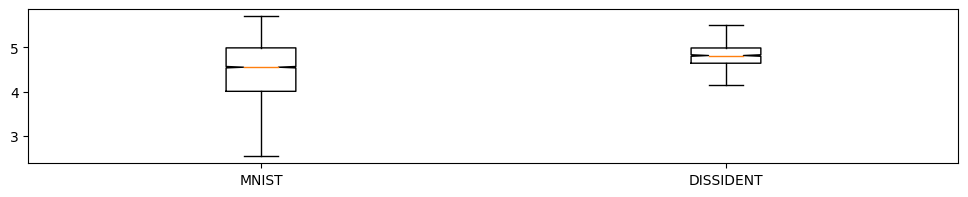

In [54]:
firings_mnist = {}
firings_mnist['MNIST'] = []
firings_mnist['DISSIDENT'] = []

with torch.no_grad():
    for data, target  in tqdm(test_loader, desc='MNIST HIST'):
        data = data.view((-1,1,28,28)).to(device)
        rates = get_arate_val(data)
        for f, l in  zip(rates, target):
            if l != mnist_class_anomaly:
                firings_mnist['MNIST'].append(f)
            else:
                firings_mnist['DISSIDENT'].append(f)
        

labels, data = firings_mnist.keys(), firings_mnist.values()

fig = plt.figure(figsize =(12, 2))
plt.boxplot(data, notch=True, showfliers=False)
plt.xticks(range(1, len(labels) + 1), labels)
plt.show()

writer.add_figure('Anomaly Detection', fig)

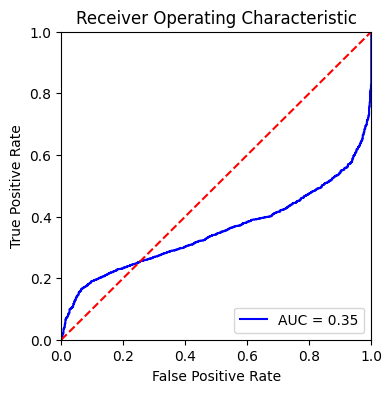

In [55]:
with torch.no_grad():
    firing_levels = []
    lab_true = []
    lab_pred = []

    for data, lab  in tqdm(test_loader, desc='Test MNIST', disable=True):
        data = data.view((-1,1,28,28)).to(device)
        rates = get_arate_val(data)
        
        for f, l in  zip(rates, lab):
            firing_levels.append(f)
            lab_pred.append(f)        
            if l == mnist_class_anomaly:
                lab_true.append(0)
            else:
                lab_true.append(1)
                    
    fpr, tpr, threshold = metrics.roc_curve(lab_true, lab_pred)
    roc_auc = metrics.auc(fpr, tpr)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = threshold[optimal_idx]
    fig = plt.figure(figsize =(4, 4))
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    writer.add_figure('ROC', fig)

EMNIST VIS:   0%|          | 0/40 [00:00<?, ?it/s]

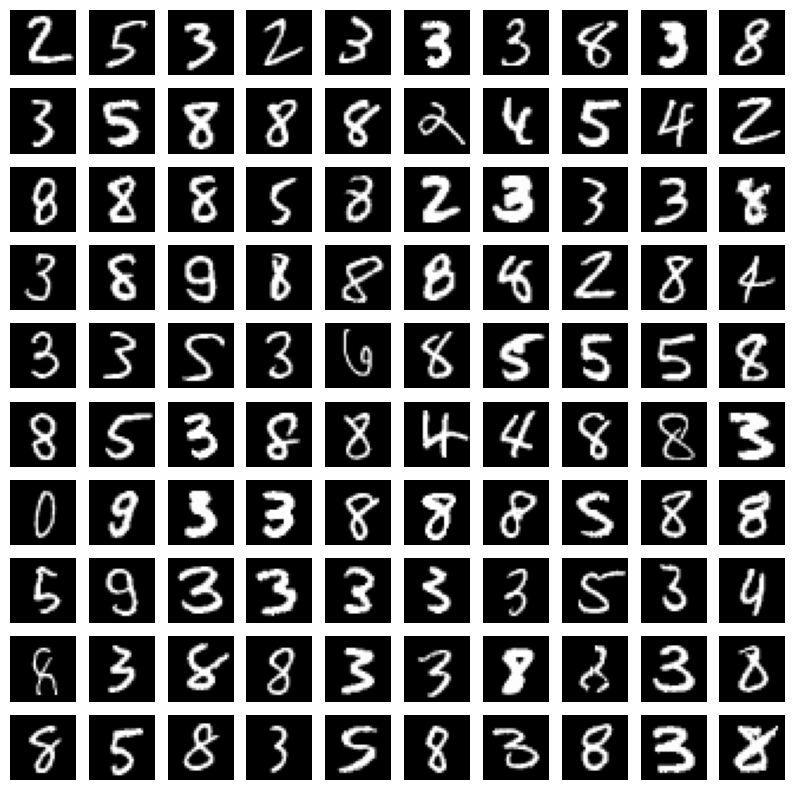

In [56]:
threshold = optimal_threshold
n = 0
fig, ax = plt.subplots(10, 10, figsize=(10, 10))
with torch.no_grad():
    for data, labels  in tqdm(test_loader, desc='EMNIST VIS'):
        if n >= 100:
            break
        data = data.view((-1, 1, 28, 28)).to(device) 
        
        arate = get_arate_val(data)
        
        for i in range(data.shape[0]):
            if(arate[i] > threshold):
                img = data[i]
                ax[int(n / 10), int(n % 10)].imshow(img.view(28, 28).cpu().detach().numpy(), cmap='gray')
                ax[int(n / 10), int(n % 10)].axis('off')
                n = n + 1
                    
                if n >= 100:
                    break